In [195]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [196]:
class Value:

 def __init__(self, data, _children=(), _op='' , label = ''):
  self.data = data
  self.grad = 0.0
  self._backward = lambda : None
  self._prev = set(_children)
  self._op = _op
  self.label = label

 def __repr__(self):
  return f"Value(data={self.data})"

 def __add__(self,other):
  other = other if isinstance(other, Value) else Value(other)
  out = Value(self.data + other.data , (self,other) , '+')

  def _backward():
    self.grad += 1.0*out.grad
    other.grad += 1.0*out.grad
  out._backward = _backward
  return out

 def __mul__(self,other):
  other = other if isinstance(other, Value) else Value(other)
  out = Value(self.data*other.data , (self,other) , '*')

  def _backward():
    self.grad += other.data * out.grad
    other.grad += self.data * out.grad
  out._backward = _backward
  return out

 def __pow__(self,other):
  assert isinstance(other , (int,float)) , "only int or float supported"
  out = Value(self.data**other , (self,) ,f'**{other}')

  def _backward():
    self.grad += other * self.data ** (other - 1)
  out._backward = _backward
  return out


 def __truediv__(self,other):
  return self * other ** -1

 def _neg__(self):
  return self * -1

 def __sub__(self,other):
  return self + (-other)

 def __rmul__(self,other):
  return self*other

 def tanh(self):
    x = self.data
    t = ((math.exp(2*x) -1)/(math.exp(2*x) +1))
    out = Value(t , (self,) ,'tanh')

    def _backward():
      self.grad  += (1 - t**2) * out.grad
    out._backward = _backward
    return out

 def exp(self):
    x = self.data
    out = Value(math.exp(x) , (self,) ,'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward

    return out

 def backward(self):

    topo =[]
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()


 def __radd__(self, other):
    return self + other





In [197]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data , n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

b: 6.7
n: 0.7000000000000002
o: 0.6043677771171636


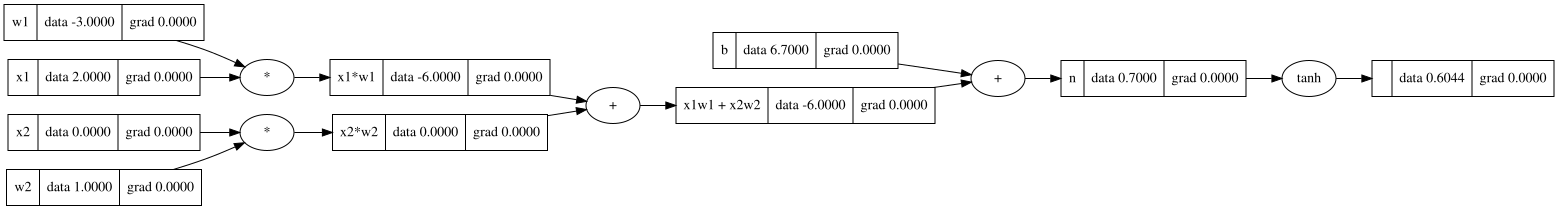

In [198]:
# inputs are x1,x2
x1 = Value(2.0 , label='x1')
x2 = Value(0.0 , label ='x2')
# weights are  w1,w2
w1 = Value(-3.0 , label = 'w1')
w2 = Value(1.0 , label = 'w2')
# biases is b
b = Value(6.7 , label ='b')
# X1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b ; n.label = 'n'
o = n.tanh()
print("b:", b.data)
print("n:", n.data)
print("o:", o.data)
draw_dot(o)



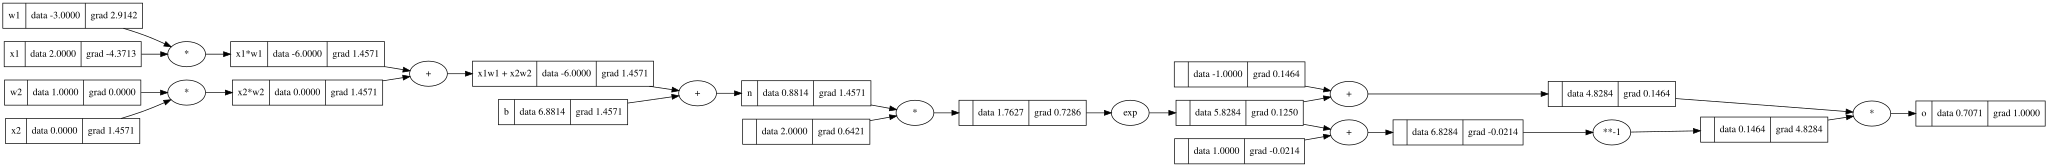

In [199]:
# inputs are x1,x2
x1 = Value(2.0 , label='x1')
x2 = Value(0.0 , label ='x2')
# weights are  w1,w2
w1 = Value(-3.0 , label = 'w1')
w2 = Value(1.0 , label = 'w2')
# biases is b
b = Value(6.8813735870195432 , label ='b')
# X1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b ; n.label = 'n'
e = (2*n).exp()
o = (e-1)/(e+1)
o.label = 'o'
o.backward()
draw_dot(o)


In [200]:
import torch

x1 = torch.Tensor([2.0]).double()                   ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                   ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()                  ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                   ; w2.requires_grad = True
b  = torch.Tensor([6.8813735870195432]).double()    ; b.requires_grad = True
n  = x1*w1 + x2*w2 + b
o  = torch.tanh(n)

print(o.data.item())
o.backward()


print('---')
print('x2' , x2.grad.item())
print('w2' , w2.grad.item())
print('x1' , x1.grad.item())
print('w1' , w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [201]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    act = sum((wi*xi for wi, xi in zip(self.w , x)) , self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w +[self.b]


class Layer:

  def __init__(self, nin ,nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]




class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i] , sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [202]:
x  = [2.0 , 3.0 , -1.0]
n  = MLP(3, [4, 4, 1])
n(x)

Value(data=0.6911804525732774)

In [203]:
len(n.parameters())

41

In [204]:
xs = [
     [2.0 , 3.0 , -1.0],
     [3.0 , -1.0 , 0.5],
     [0.5 , 1.0 , 1.0],
     [1.0 , 1.0, -1.0],
 ]

ys = [ 1.0 , -1.0 , -1.0 , 1.0]

In [205]:
for k in range(20):
  #forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  #backward pass

  for p in n.parameters():
    p.grad  = 0.0
  loss.backward()

  #update
  for p in n.parameters():
    p.data += -0.05 * p.grad

  print(k , loss.data)



0 6.036486214116315
1 5.031941443421993
2 4.01946709771983
3 3.2719608602389383
4 2.8310372729285547
5 2.5375577386657664
6 2.2392512266592566
7 1.8456185343031
8 1.3329044410081567
9 0.8416096080964838
10 0.5266408087029338
11 0.3571225241921367
12 0.26208508537116815
13 0.2039041917634915
14 0.16543392914907035
15 0.138421565792686
16 0.11855327733242588
17 0.10339803145336915
18 0.09149674254692651
19 0.0819269089938801


In [206]:
ypred

[Value(data=0.8695087005968362),
 Value(data=-0.9326417045488504),
 Value(data=-0.816186105668043),
 Value(data=0.8369839208593529)]

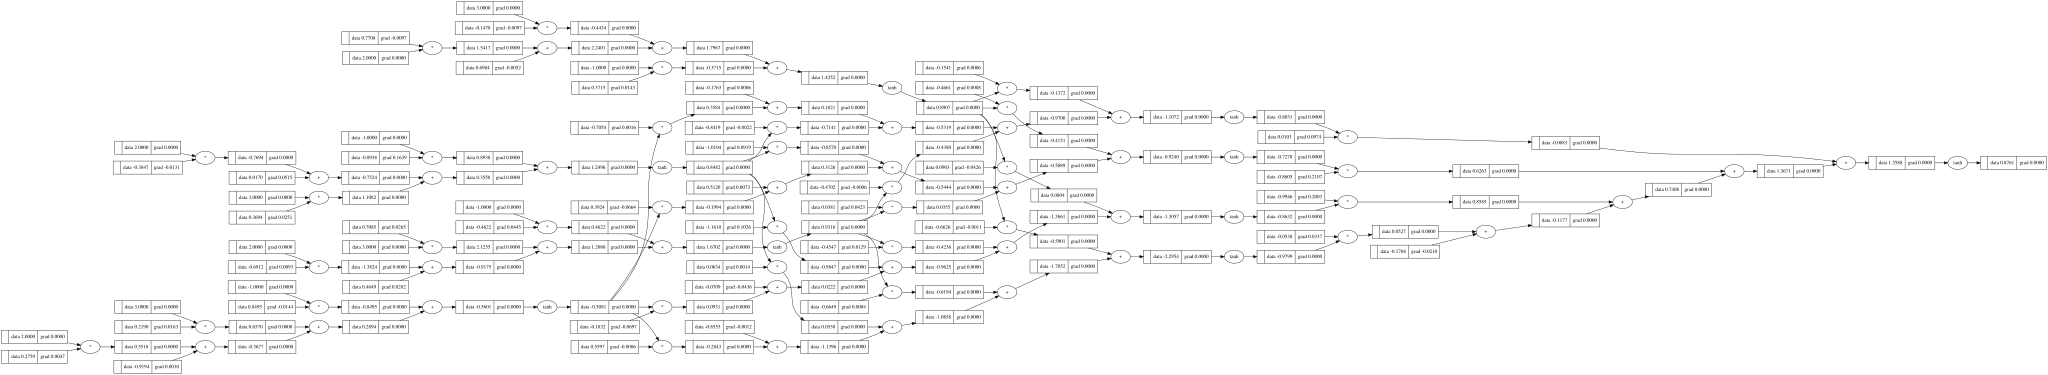

In [209]:
 draw_dot(n(x))

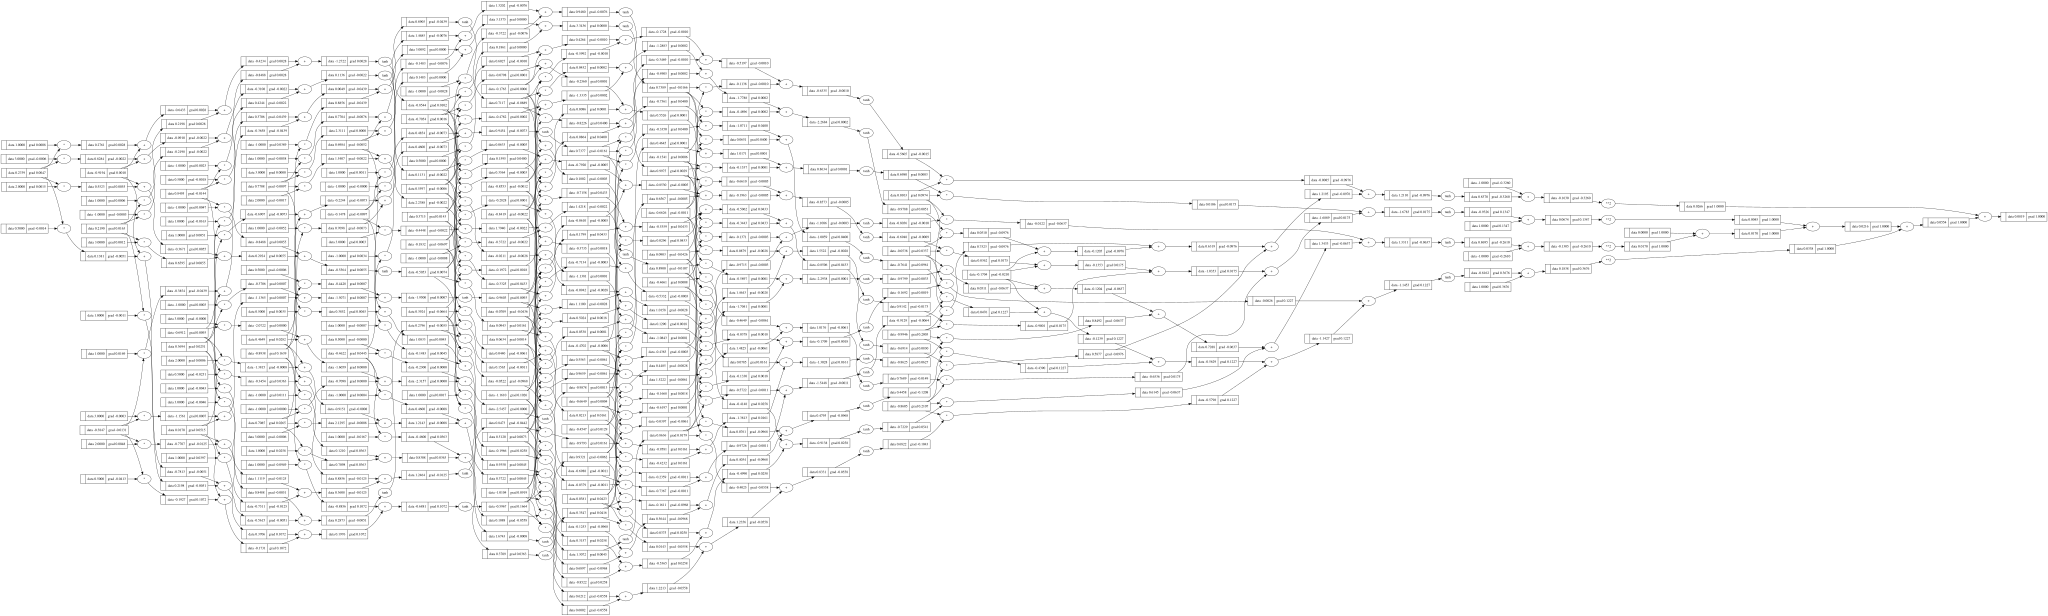

In [210]:
draw_dot(loss)